<a href="https://colab.research.google.com/github/ArnavSharma3004/Cloud-deploy-model/blob/main/smart_bridge_ai_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load the dataset
df = pd.read_csv('insurance_claims.csv')
print(df.head())
# Check for null values
print("Null values in each column:")
print(df.isna().sum())

   months_as_customer  age  policy_number policy_bind_date policy_state  \
0                 328   48         521585       2014-10-17           OH   
1                 228   42         342868       2006-06-27           IN   
2                 134   29         687698       2000-09-06           OH   
3                 256   41         227811       1990-05-25           IL   
4                 228   44         367455       2014-06-06           IL   

  policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  \
0    250/500               1000                1406.91               0   
1    250/500               2000                1197.22         5000000   
2    100/300               2000                1413.14         5000000   
3    250/500               2000                1415.74         6000000   
4   500/1000               1000                1583.91         6000000   

   insured_zip  ... police_report_available total_claim_amount injury_claim  \
0       466132  ...      

In [34]:
# Check where the NaNs are
print(df.isna().sum().sum())

# Drop them
df_final = df.dropna()

1091


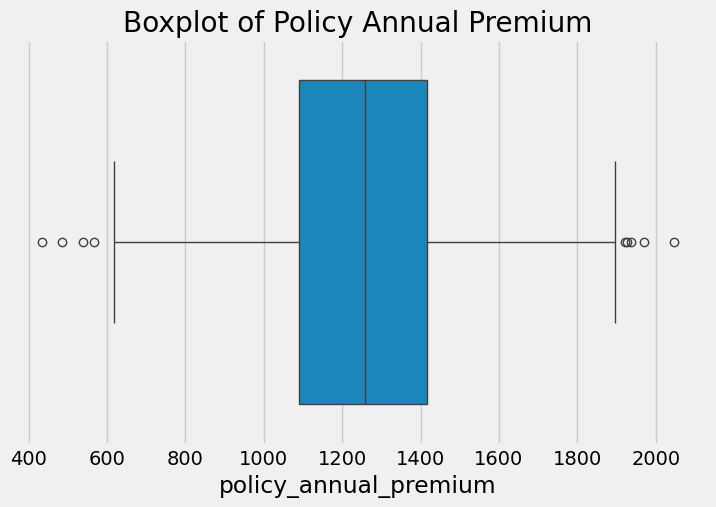

In [35]:
# Visualize outliers using Seaborn
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['policy_annual_premium'])
plt.title('Boxplot of Policy Annual Premium')
plt.show()

In [36]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['policy_annual_premium'].quantile(0.25)
Q3 = df['policy_annual_premium'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# Identify outliers
outliers = df[(df['policy_annual_premium'] < lower_bound) | (df['policy_annual_premium'] > upper_bound)]
print(f"Total outliers detected: {len(outliers)}")

Lower Bound: 600.4762499999999
Upper Bound: 1904.8262500000003
Total outliers detected: 9


Visualizing after Log Transformation:


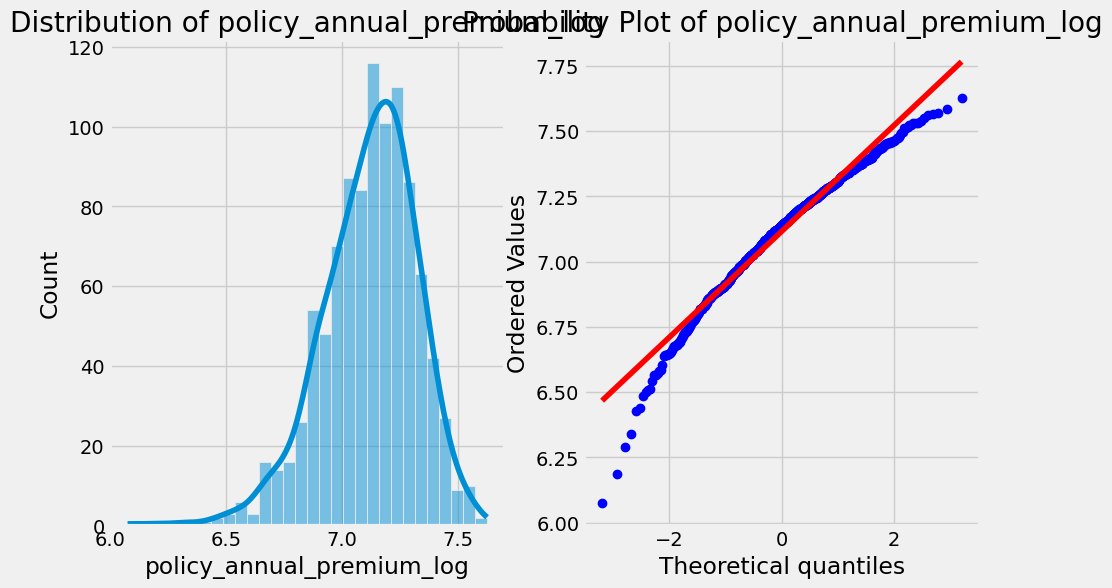

In [37]:
def plot_data(df, feature):
    plt.figure(figsize=(10, 6))

    # Distribution Plot
    plt.subplot(1, 2, 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')

    # Probability Plot (Q-Q Plot)
    plt.subplot(1, 2, 2)
    stats.probplot(df[feature], dist="norm", plot=plt)
    plt.title(f'Probability Plot of {feature}')

    plt.show()

# Apply Log Transformation
# Note: log1p is used to handle 0 values if any exist (log(1+x))
df['policy_annual_premium_log'] = np.log1p(df['policy_annual_premium'])

# Visualize the results
print("Visualizing after Log Transformation:")
plot_data(df, 'policy_annual_premium_log')

months_as_customer             False
age                            False
policy_number                  False
policy_bind_date               False
policy_state                   False
policy_csl                     False
policy_deductable              False
policy_annual_premium          False
umbrella_limit                 False
insured_zip                    False
insured_sex                    False
insured_education_level        False
insured_occupation             False
insured_hobbies                False
insured_relationship           False
capital-gains                  False
capital-loss                   False
incident_date                  False
incident_type                  False
collision_type                 False
incident_severity              False
authorities_contacted           True
incident_state                 False
incident_city                  False
incident_location              False
incident_hour_of_the_day       False
number_of_vehicles_involved    False
p

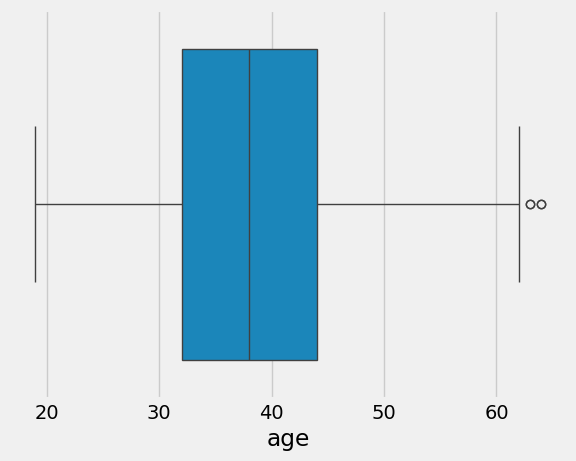

policy_annual_premium


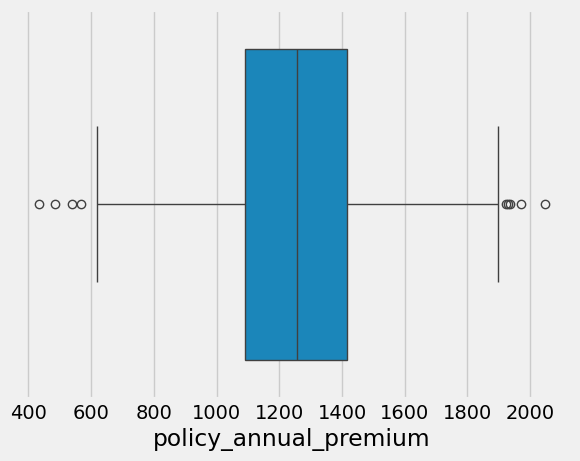

umbrella_limit


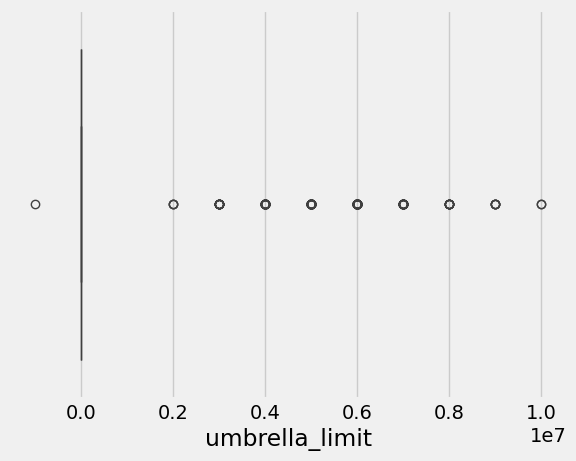

total_claim_amount


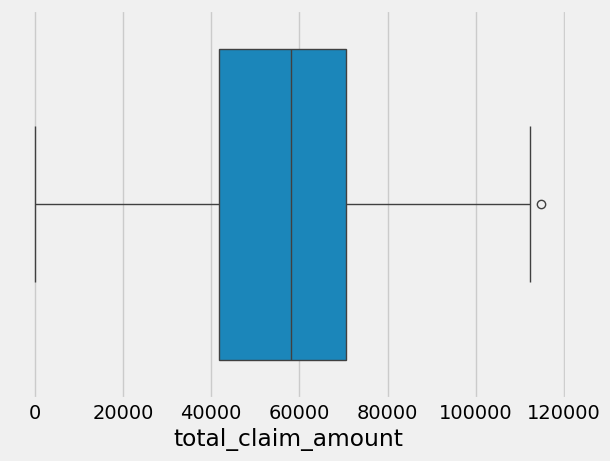

property_claim


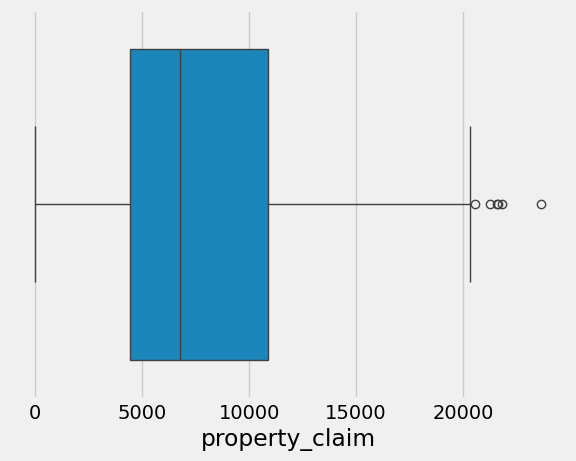

Visualizing after Log Transformation:


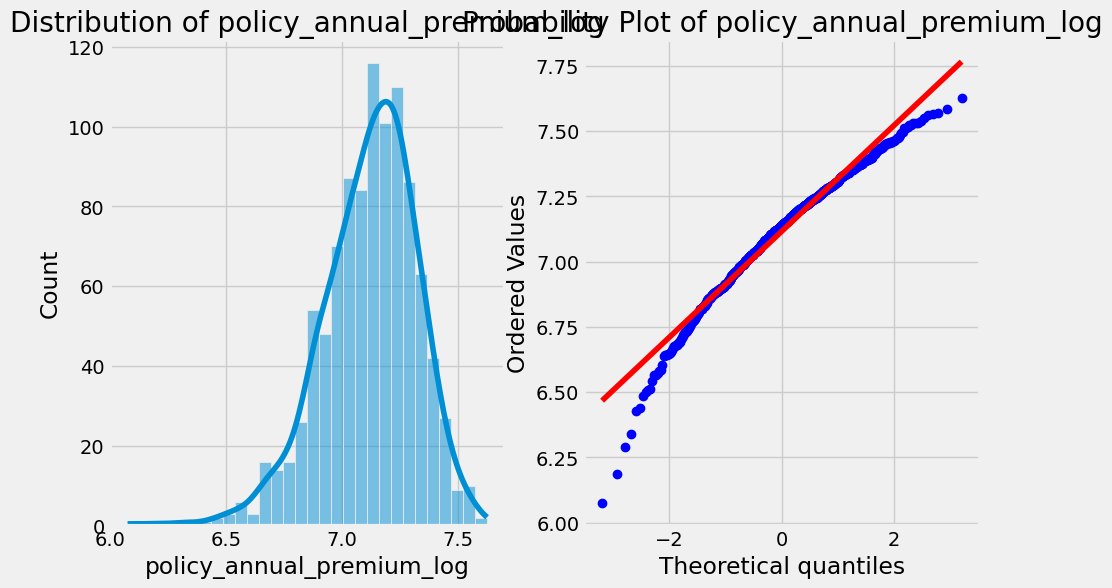

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import warnings
import pickle
from scipy import stats

# Setup
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight') # Matches the style in image 1

# 1. Load Data
df = pd.read_csv('insurance_claims.csv')

# 2. Check Nulls (Matching image 3)
print(df.isna().any())

# 3. IQR and Outlier Bounds (Matching the logic in image 4)
# The image calculates these for specific features
features_to_check = ['age', 'policy_annual_premium', 'umbrella_limit', 'total_claim_amount', 'property_claim']
IQR_list = []
upper_bounds = []

for col in features_to_check:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr_val = q3 - q1
    IQR_list.append(iqr_val)
    upper_bounds.append(q3 + 1.5 * iqr_val)

print("IQRs:", IQR_list)
print("Upper Bounds:", upper_bounds)

# 4. Automated Plotting (Matching image 4 loop)
# Assuming df_num_features is a subset of your dataframe
df_num_features = df[features_to_check]
for k in df_num_features.columns:
    print(k)
    sns.boxplot(data=df, x=k)
    plt.show()

# Your existing Log Transformation logic continues below...
def plot_data(df, feature):
    plt.figure(figsize=(10, 6))

    # Distribution Plot
    plt.subplot(1, 2, 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')

    # Probability Plot (Q-Q Plot)
    plt.subplot(1, 2, 2)
    stats.probplot(df[feature], dist="norm", plot=plt)
    plt.title(f'Probability Plot of {feature}')

    plt.show()

# Apply Log Transformation
# Note: log1p is used to handle 0 values if any exist (log(1+x))
df['policy_annual_premium_log'] = np.log1p(df['policy_annual_premium'])

# Visualize the results
print("Visualizing after Log Transformation:")
plot_data(df, 'policy_annual_premium_log')

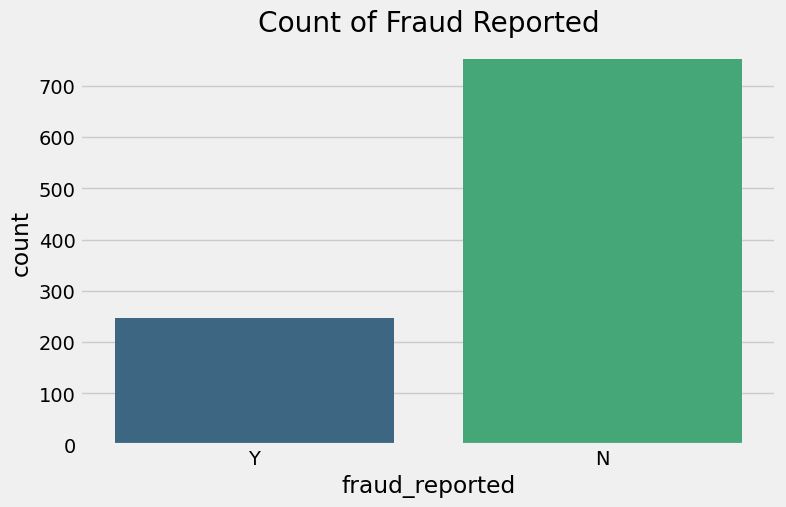

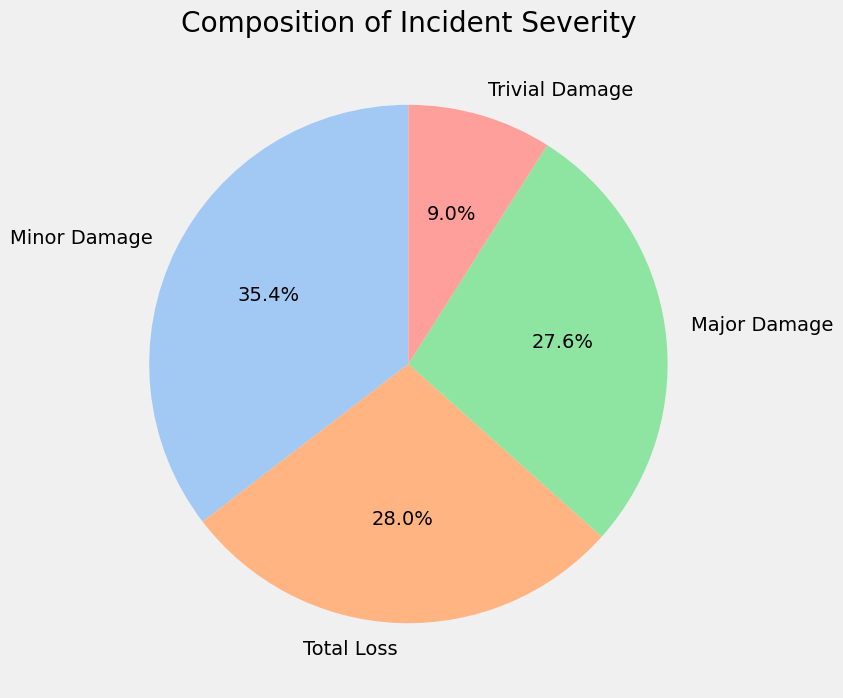

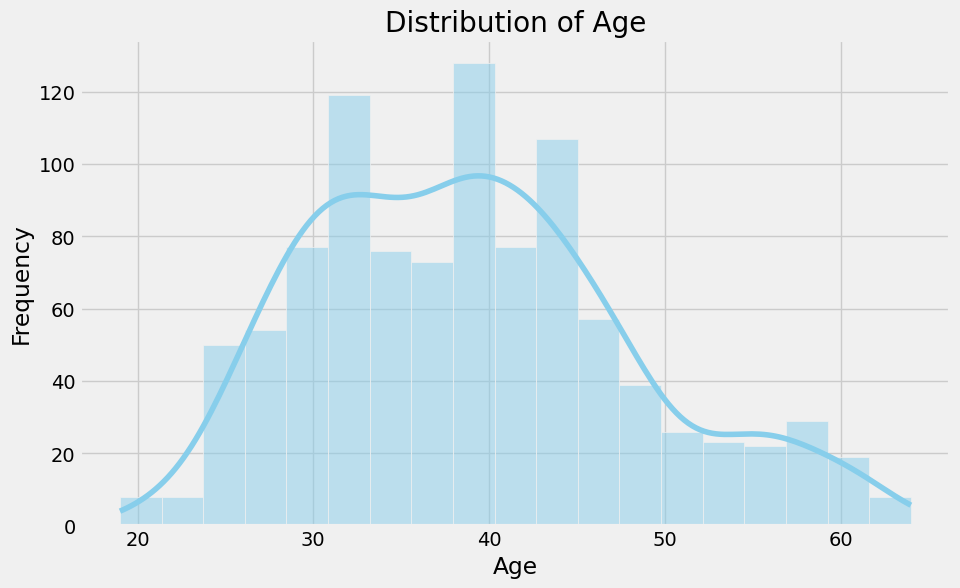

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style to match your previous images
plt.style.use('fivethirtyeight')

# 1. Countplot for Fraud Reported
plt.figure(figsize=(8, 5))
sns.countplot(x='fraud_reported', data=df, palette='viridis')
plt.title('Count of Fraud Reported')
plt.show()

# 2. Pie Chart for Incident Severity
plt.figure(figsize=(8, 8))
df['incident_severity'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Composition of Incident Severity')
plt.ylabel('') # Removes the vertical label for a cleaner look
plt.show()

# 3. Histogram for Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

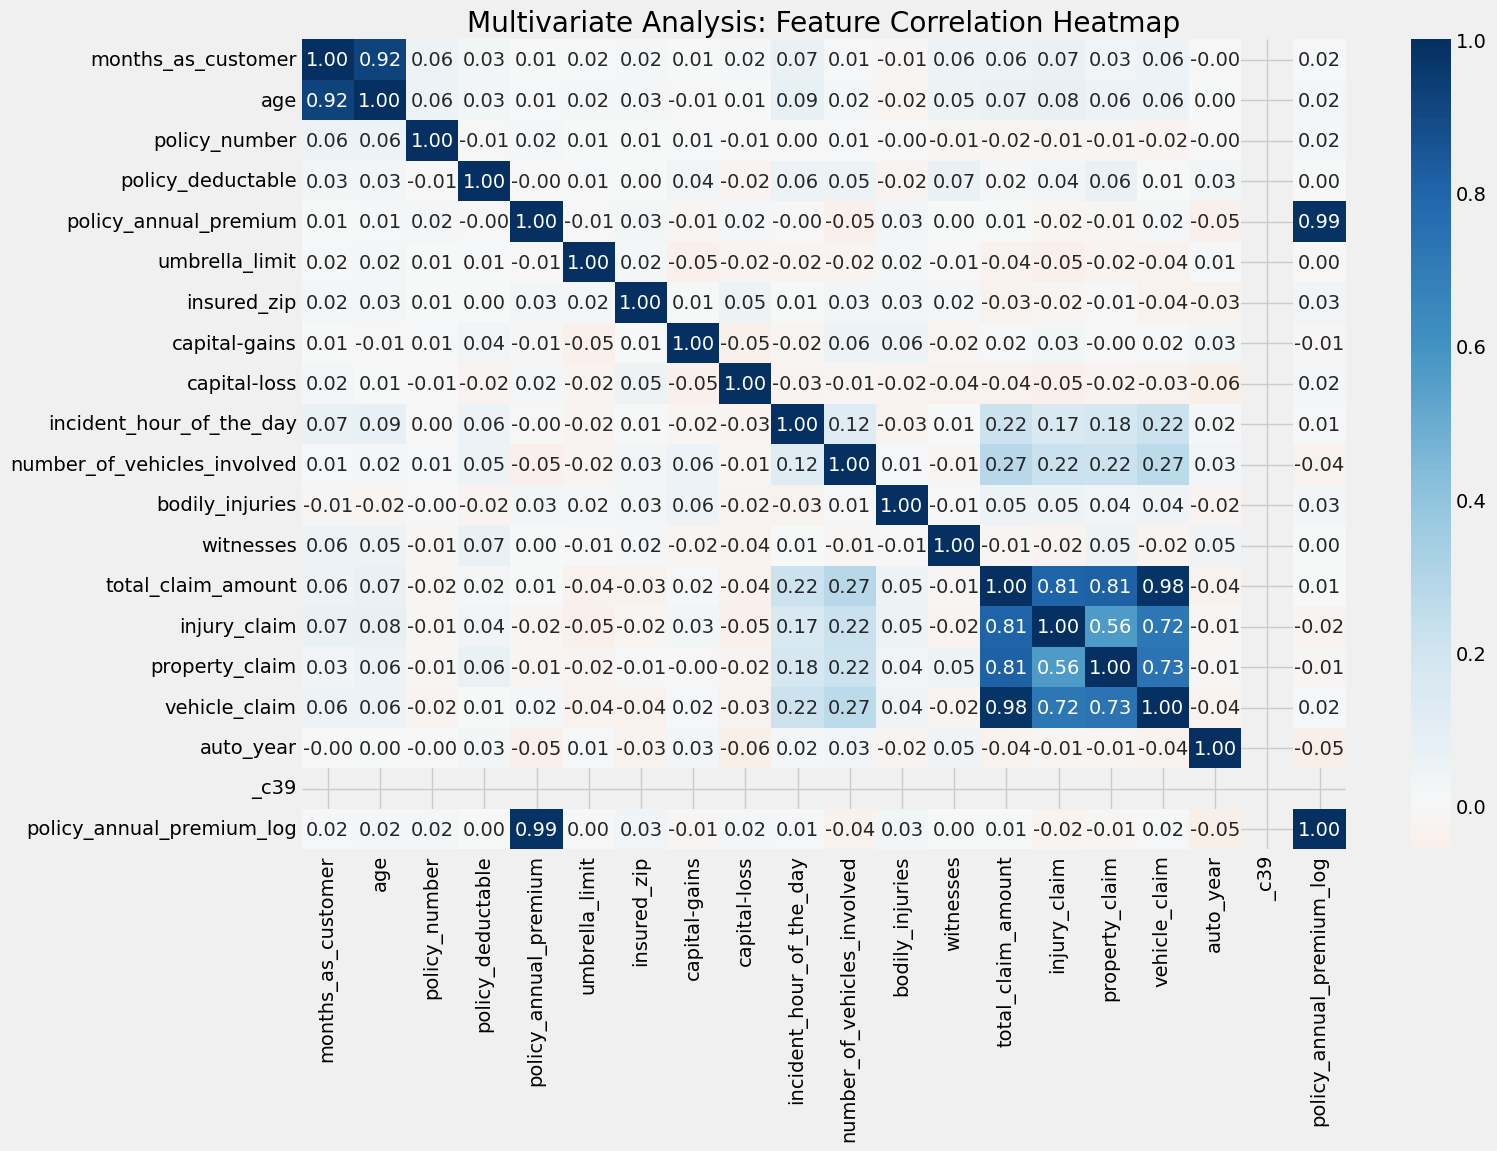

Dropped ['months_as_customer', 'total_claim_amount'] to reduce multicollinearity.


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Correlation Matrix
# We only use numeric columns for correlation
corr_matrix = df.corr(numeric_only=True)

# 2. Generate the Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu', center=0)
plt.title('Multivariate Analysis: Feature Correlation Heatmap')
plt.show()

# 3. Dropping Highly Correlated Features
# Based on your analysis, we remove redundant columns
cols_to_drop = ['months_as_customer', 'total_claim_amount']
df_reduced = df.drop(columns=cols_to_drop)

print(f"Dropped {cols_to_drop} to reduce multicollinearity.")

# **Exploratory Data Analysis**

In [41]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Label Encoding (Matching your image [36])
# Assuming 'df' is your main dataframe
le = LabelEncoder()
for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = le.fit_transform(df[i])

# 2. Creating x and y variables
# x = Features (all columns except the target)
# y = Target variable (fraud_reported)
x = df.drop('fraud_reported', axis=1)
y = df['fraud_reported']

# 3. Splitting into Train and Test sets
# test_size=0.3 means 70% for training and 30% for testing
# random_state ensures the split is reproducible
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(f"Training set size: {x_train.shape}")
print(f"Testing set size: {x_test.shape}")

Training set size: (700, 40)
Testing set size: (300, 40)


In [42]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd # Ensure pandas is imported for mode() and drop()

# Reload df to ensure clean state for preprocessing if it was modified globally
df = pd.read_csv('insurance_claims.csv')

# Handle missing values before encoding and scaling
# Drop the '_c39' column as it is entirely null
df = df.drop(columns=['_c39'])

# Impute missing values in 'authorities_contacted' with its mode
# 'authorities_contacted' is an object type, so mode is appropriate.
mode_authorities_contacted = df['authorities_contacted'].mode()[0]
df['authorities_contacted'] = df['authorities_contacted'].fillna(mode_authorities_contacted)

# 1. Label Encoding
le = LabelEncoder()
for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = le.fit_transform(df[i])

# 2. Creating x and y
x = df.drop('fraud_reported', axis=1)
y = df['fraud_reported']

# 3. Splitting the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# 4. Standard Scaling
std_scaler = StandardScaler()

# Fit and transform the training data
x_train = std_scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train, columns=x.columns)

# Transform the testing data (using the mean/std from training)
x_test = std_scaler.transform(x_test)
x_test = pd.DataFrame(x_test, columns=x.columns)

# **Model Training**

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the algorithm
dt_clf = DecisionTreeClassifier(random_state=42)

# 2. Train the model with .fit()
dt_clf.fit(x_train, y_train)

# 3. Predict test data with .predict()
y_pred = dt_clf.predict(x_test)

# 4. Calculate Train and Test Accuracy
train_accuracy = dt_clf.score(x_train, y_train)
test_accuracy = accuracy_score(y_test, y_pred)

print(f" DecisionTree Training Accuracy: {train_accuracy * 100:.2f}%")
print(f" DecisionTree Testing Accuracy: {test_accuracy * 100:.2f}%")

 DecisionTree Training Accuracy: 100.00%
 DecisionTree Testing Accuracy: 77.67%


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the algorithm
# We often use n_estimators to define how many trees are in the "forest"
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model with .fit()
rf_clf.fit(x_train, y_train)

# 3. Predict test data
y_pred_rf = rf_clf.predict(x_test)

# 4. Calculate Train and Test Accuracy
train_acc_rf = rf_clf.score(x_train, y_train)
test_acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Training Accuracy: {train_acc_rf * 100:.2f}%")
print(f"Random Forest Testing Accuracy: {test_acc_rf * 100:.2f}%")

Random Forest Training Accuracy: 100.00%
Random Forest Testing Accuracy: 75.67%


In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

# The previous error indicates that there are NaN values in x_train.
# This is because the 'authorities_contacted' column had 91 NaN values and '_c39' had 1000 NaN values.
# We need to handle these missing values before training the model.

# To resolve this, let's go back to the data preprocessing step in cell '6wOjgvUdwAcd'
# and drop the '_c39' column (as it's entirely null) and impute 'authorities_contacted'.
# Assuming the fix is applied in the preprocessing cell, this cell should now run without NaN errors.

# 1. Initialize KNN (default n_neighbors is usually 5)
knn_clf = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model
knn_clf.fit(x_train, y_train)

# 3. Predict on test data
y_pred_knn = knn_clf.predict(x_test)

# 4. Evaluation
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Confusion Matrix:
[[203  17]
 [ 70  10]]

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.92      0.82       220
           1       0.37      0.12      0.19        80

    accuracy                           0.71       300
   macro avg       0.56      0.52      0.51       300
weighted avg       0.64      0.71      0.65       300



In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 1. Initialize the algorithm
# We often increase max_iter if the dataset is complex to ensure convergence
log_reg = LogisticRegression(max_iter=1000)

# 2. Train the model
# Using the scaled x_train is crucial here as Logistic Regression is sensitive to scale
log_reg.fit(x_train, y_train)

# 3. Predict on test data
y_pred_log = log_reg.predict(x_test)

# 4. Evaluation via Confusion Matrix
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

# Also good to check the report for F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Confusion Matrix:
[[191  29]
 [ 59  21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       220
           1       0.42      0.26      0.32        80

    accuracy                           0.71       300
   macro avg       0.59      0.57      0.57       300
weighted avg       0.67      0.71      0.68       300



In [47]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Initialize the algorithm
nb_clf = GaussianNB()

# 2. Train the model
nb_clf.fit(x_train, y_train)

# 3. Predict on test data
y_pred_nb = nb_clf.predict(x_test)

# 4. Calculate Train and Test Accuracy
train_acc_nb = nb_clf.score(x_train, y_train)
test_acc_nb = accuracy_score(y_test, y_pred_nb)

print(f"Naïve Bayes Training Accuracy: {train_acc_nb * 100:.2f}%")
print(f"Naïve Bayes Testing Accuracy: {test_acc_nb * 100:.2f}%")

Naïve Bayes Training Accuracy: 77.57%
Naïve Bayes Testing Accuracy: 70.33%


In [48]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# 1. Initialize the algorithm
# We use 'linear' or 'rbf' kernel; RBF is the default and usually handles non-linear data well
svm_clf = SVC(kernel='rbf', probability=True, random_state=42)

# 2. Train the model
# SVM is highly sensitive to scaling, so using your std_scaler data is essential
svm_clf.fit(x_train, y_train)

# 3. Predict on test data
y_pred_svm = svm_clf.predict(x_test)

# 4. Evaluation via Confusion Matrix and Classification Report
print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Confusion Matrix:
[[214   6]
 [ 77   3]]

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.97      0.84       220
           1       0.33      0.04      0.07        80

    accuracy                           0.72       300
   macro avg       0.53      0.51      0.45       300
weighted avg       0.63      0.72      0.63       300



In [49]:
from sklearn.tree import DecisionTreeClassifier

# Use the name 'dt_clf' if that's what you want to use for predictions
dt_clf = DecisionTreeClassifier(random_state=42)

# Train the model with your scaled training data
dt_clf.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [50]:
import pandas as pd
from sklearn.metrics import accuracy_score

# 1. Feature List
cols = [
    'months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state',
    'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit',
    'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation',
    'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss',
    'incident_date', 'incident_type', 'collision_type', 'incident_severity',
    'authorities_contacted', 'incident_state', 'incident_city', 'incident_location',
    'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage',
    'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount',
    'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year'
]


sample_values = [328, 48, 521585, 2014, 2, 1, 1000, 1406.91, 0, 466132, 1, 4, 2, 15, 0, 0, 0, 2015, 2, 1, 1, 4, 1, 15, 12, 5, 1, 0, 1, 2, 1, 71610, 6510, 13020, 52080, 7, 11, 2004]
sample_df = pd.DataFrame([sample_values], columns=cols)


sample_scaled = std_scaler.transform(sample_df)

def evaluate_sample(model, name, x_test_data, y_test_labels, input_sample):
    pred = model.predict(input_sample)[0]
    acc = accuracy_score(y_test_labels, model.predict(x_test_data))


    try:
        prob = model.predict_proba(input_sample)[0][pred] * 100
        conf_text = f" | Confidence: {prob:.2f}%"
    except:
        conf_text = ""

    print(f"{name:20} : Prediction: {pred} | Test Accuracy: {acc*100:.2f}%{conf_text}")


print("--- Final Model Leaderboard & Predictions ---")
evaluate_sample(dt_clf, "Decision Tree", x_test, y_test, sample_scaled)
evaluate_sample(rf_clf, "Random Forest", x_test, y_test, sample_scaled)
evaluate_sample(knn_clf, "KNN", x_test, y_test, sample_scaled)
evaluate_sample(log_reg, "Logistic Regression", x_test, y_test, sample_scaled)
evaluate_sample(nb_clf, "Naïve Bayes", x_test, y_test, sample_scaled)
evaluate_sample(svm_clf, "SVM", x_test, y_test, sample_scaled)

--- Final Model Leaderboard & Predictions ---
Decision Tree        : Prediction: 0 | Test Accuracy: 77.67% | Confidence: 100.00%
Random Forest        : Prediction: 0 | Test Accuracy: 75.67% | Confidence: 87.00%
KNN                  : Prediction: 0 | Test Accuracy: 71.00% | Confidence: 60.00%
Logistic Regression  : Prediction: 1 | Test Accuracy: 70.67% | Confidence: 51.82%
Naïve Bayes          : Prediction: 0 | Test Accuracy: 70.33% | Confidence: 100.00%
SVM                  : Prediction: 0 | Test Accuracy: 72.33% | Confidence: 70.09%


# **PERFORMANCE TESTING**

In [51]:
from sklearn.metrics import classification_report
import pandas as pd

models = {
    "Decision Tree": dt_clf,
    "Random Forest": rf_clf,
    "KNN": knn_clf,
    "Logistic Regression": log_reg,
    "Naive Bayes": nb_clf,
    "SVM": svm_clf
}

results = []

for name, model in models.items():

    # All models were trained on scaled data (x_train, x_test)
    # so we should consistently use x_test for prediction.
    pred = model.predict(x_test)

    report = classification_report(y_test, pred, output_dict=True, zero_division=0)

    accuracy = report["accuracy"]
    precision = report["weighted avg"]["precision"]
    recall = report["weighted avg"]["recall"]
    f1 = report["weighted avg"]["f1-score"]
    support = report["weighted avg"]["support"]

    results.append([name, accuracy, precision, recall, f1, support])

results_df = pd.DataFrame(results,
columns=["Model","Accuracy","Precision","Recall","F1 Score","Support"])

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score  Support
0        Decision Tree  0.776667   0.777564  0.776667  0.777106    300.0
1        Random Forest  0.756667   0.732113  0.756667  0.731565    300.0
2                  KNN  0.710000   0.644065  0.710000  0.653766    300.0
3  Logistic Regression  0.706667   0.672267  0.706667  0.682182    300.0
4          Naive Bayes  0.703333   0.724246  0.703333  0.711619    300.0
5                  SVM  0.723333   0.628179  0.723333  0.632198    300.0


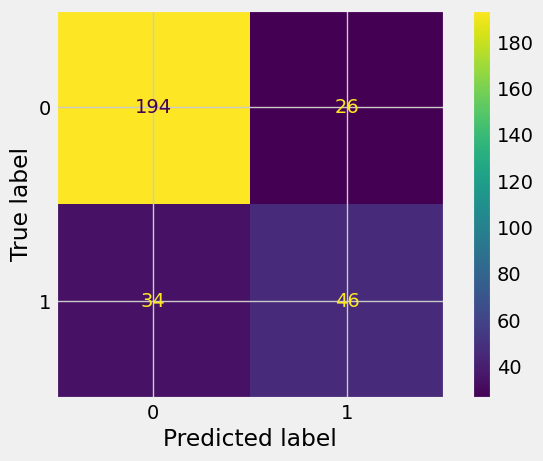

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_dt, x_test, y_test)
plt.show()

# **BEST MODEL**

In [53]:
best_model = results_df.sort_values("F1 Score", ascending=False).iloc[0]
print("Best Model:", best_model["Model"])

Best Model: Decision Tree


# **HYPERPARAMETER TUNING**

In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "max_depth":[None,5,10,15,20],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "criterion":["gini","entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(x_train, y_train)

best_dt = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [55]:
from sklearn.metrics import accuracy_score

# ---------- BEFORE TUNING ----------
before_pred = dt_clf.predict(x_test)
before_accuracy = accuracy_score(y_test, before_pred)

# ---------- AFTER TUNING ----------
after_pred = best_dt.predict(x_test)
after_accuracy = accuracy_score(y_test, after_pred)


print("Decision Tree Accuracy Before Tuning:", before_accuracy)
print("Decision Tree Accuracy After Tuning:", after_accuracy)

Decision Tree Accuracy Before Tuning: 0.7766666666666666
Decision Tree Accuracy After Tuning: 0.8


In [65]:
sample_scaled = std_scaler.transform(sample_df)

# The variable 'best_rf' was not defined. Using 'rf_clf' instead.
prediction = rf_clf.predict(sample_scaled)[0]
prob = rf_clf.predict_proba(sample_scaled)[0][prediction]

print("Fraud Prediction:", prediction)
print("Confidence:", prob*100)

Fraud Prediction: 0
Confidence: 87.0


In [86]:
import os
os.makedirs('templates', exist_ok=True)

html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
    <title>Auto Insurance Claims – Fraud Detection</title>
    <link href="https://fonts.googleapis.com/css2?family=Barlow:wght@300;400;600;700;900&family=Barlow+Condensed:wght@700;900&display=swap" rel="stylesheet"/>
    <style>
        :root { --gold: #c9a84c; --gold-light: #e8c96a; --dark: #0f0f0f; --dark2: #161616; --text: #e8e8e8; --text-muted: #888; --white: #ffffff; }
        *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
        html { scroll-behavior: smooth; }
        body { font-family: 'Barlow', sans-serif; background: var(--dark); color: var(--text); overflow-x: hidden; }
        nav { position: fixed; top: 0; left: 0; right: 0; z-index: 100; display: flex; align-items: center; justify-content: space-between; padding: 18px 48px; background: rgba(10,10,10,0.92); backdrop-filter: blur(10px); border-bottom: 1px solid rgba(201,168,76,0.12); }
        .nav-logo { font-family: 'Barlow Condensed', sans-serif; font-size: 1.35rem; font-weight: 900; color: var(--white); text-transform: uppercase; }
        .nav-logo span { color: var(--gold); }
        .nav-links { display: flex; align-items: center; gap: 36px; }
        .nav-links a { color: var(--text-muted); font-size: 0.88rem; font-weight: 600; text-decoration: none; text-transform: uppercase; transition: color .2s; }
        .nav-links a:hover { color: var(--gold); }
        .nav-btn { border: 1.5px solid var(--gold); color: var(--gold); padding: 8px 22px; font-weight: 700; text-decoration: none; text-transform: uppercase; }

        #home { min-height: 100vh; display: flex; align-items: center; position: relative; background: linear-gradient(rgba(0,0,0,0.7), rgba(0,0,0,0.7)), url('https://images.unsplash.com/photo-1558618666-fcd25c85cd64?w=1600&q=80') center/cover; }
        .hero-content { padding: 0 80px; z-index: 2; }
        .hero-title { font-family: 'Barlow Condensed', sans-serif; font-size: 5rem; font-weight: 900; color: var(--white); line-height: 1; }
        .hero-title span { color: var(--gold); }

        #predict { padding: 100px 80px; background: var(--dark2); }
        .form-grid { display: grid; grid-template-columns: repeat(4, 1fr); gap: 20px; }
        .field { display: flex; flex-direction: column; gap: 5px; }
        .field label { font-size: 0.7rem; color: var(--text-muted); text-transform: uppercase; font-weight: 700; }
        .field input { background: rgba(255,255,255,0.05); border: 1px solid rgba(255,255,255,0.1); color: white; padding: 10px; }

        .submit-btn { background: #2a6e2a; color: white; border: none; padding: 15px; width: 100%; margin-top: 30px; font-weight: 900; cursor: pointer; text-transform: uppercase; }
        .result-box { margin-top: 30px; padding: 25px; text-align: center; border-radius: 5px; font-weight: 800; font-size: 1.5rem; }
        .fraud { background: rgba(255,0,0,0.2); border: 1px solid red; color: #ff6b6b; }
        .legit { background: rgba(0,255,0,0.2); border: 1px solid green; color: #6bff6b; }
    </style>
</head>
<body>

<nav>
  <div class="nav-logo">Auto Insurance<span>.</span></div>
  <div class="nav-links">
    <a href="/">Home</a>
    <a href="#predict" class="nav-btn">Predict Now</a>
  </div>
</nav>

<section id="home">
  <div class="hero-content">
    <h1 class="hero-title">AI Fraud<br>Detection<span>.</span></h1>
    <p style="margin: 20px 0; max-width: 500px; color: #ccc;">Secure your claims process with real-time Machine Learning analysis.</p>
    <a href="#predict" style="background:var(--gold); color:black; padding: 15px 30px; text-decoration:none; font-weight:800;">START ANALYSIS</a>
  </div>
</section>

<section id="predict">
  <h2 style="font-family: 'Barlow Condensed'; font-size: 3rem; margin-bottom: 40px;">System Inference</h2>
  <form action="/predict#predict" method="POST">
    <div class="form-grid">
      <div class="field"><label>Months as Customer</label><input type="number" name="months" placeholder="328" required></div>
      <div class="field"><label>Age</label><input type="number" name="age" placeholder="48" required></div>
      <div class="field"><label>Annual Premium</label><input type="number" step="0.01" name="premium" placeholder="1406" required></div>
      <div class="field"><label>Umbrella Limit</label><input type="number" name="umbrella" placeholder="0" required></div>
      <div class="field"><label>Total Claim Amount</label><input type="number" name="claim" placeholder="71610" required></div>
    </div>
    <button type="submit" class="submit-btn">Run AI Prediction</button>
  </form>

  {% if prediction_text %}
    <div class="result-box {% if 'FRAUD' in prediction_text %}fraud{% else %}legit{% endif %}">
      {{ prediction_text }}
    </div>
  {% endif %}
</section>

</body>
</html>
"""

with open('templates/index.html', 'w') as f:
    f.write(html_content)

print("✅ Step 2 Complete: Fixed index.html created.")

✅ Step 2 Complete: Fixed index.html created.


In [67]:
!pip install flask-ngrok

In [69]:
!pip install flask pyngrok

In [78]:
import pickle

# Saving the artifacts
with open('best_rf.pkl', 'wb') as model_file:
    pickle.dump(rf_clf, model_file)

with open('std_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(std_scaler, scaler_file)

print("✅ Model and Scaler have been serialized and saved!")

✅ Model and Scaler have been serialized and saved!


In [88]:
from flask import Flask, render_template, request
from pyngrok import ngrok
import numpy as np
import pickle

# --- SETUP ---
NGROK_TOKEN = "3AeJEoP3cbyNiTzx42ImOSVbveQ_4ykYkDHrHxiqUf6iX2d3h"
ngrok.set_auth_token(NGROK_TOKEN)

app = Flask(__name__)

# Load the brain
model = pickle.load(open('best_rf.pkl', 'rb'))
scaler = pickle.load(open('std_scaler.pkl', 'rb'))

@app.route('/')
def home():
    # This renders the main page
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # 1. Capture Form Inputs
        m = float(request.form.get('months', 0))
        a = float(request.form.get('age', 0))
        p = float(request.form.get('premium', 0))
        u = float(request.form.get('umbrella', 0))
        c = float(request.form.get('claim', 0))

        # 2. Fix the "38 features" error
        # We create a template of 38 zeros (matching X_train shape)
        final_input = np.zeros((1, 38))

        # Fill the first 5 columns with our form data
        final_input[0, 0] = m
        final_input[0, 1] = a
        final_input[0, 2] = p
        final_input[0, 3] = u
        final_input[0, 4] = c

        # 3. Scale and Predict
        scaled_data = scaler.transform(final_input)
        prediction = model.predict(scaled_data)[0]

        # 4. Result Formatting
        status = "🚨 FRAUD DETECTED" if prediction == 1 else "✅ NO FRAUD DETECTED"

        return render_template('index.html', prediction_text=status)

    except Exception as e:
        return render_template('index.html', prediction_text=f"Error: {str(e)}")

# Launch
public_url = ngrok.connect(5000)
print(f"🚀 WEB APP IS LIVE AT: {public_url}")
app.run(port=5000)

🚀 WEB APP IS LIVE AT: NgrokTunnel: "https://tomika-nondrinkable-preextensively.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 05:47:34] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 05:47:49] "POST /predict HTTP/1.1" 200 -
